## O que este notebook oferece ao decisor

1. **Alocação Ótima por Cenário**  
   - Para cada simulação (“sim1”, “sim2”, “sim3” e histórico), identifica a carteira que maximiza a relação retorno/risco.  
   - Garante **mínimo de 5 %** em cada ativo e soma total de 100 %.

2. **Trade-off Risco × Retorno**  
   - Mostra o **retorno esperado** e o **risco (σ)** diário de cada portfólio ótimo.  
   - Calcula o **Sharpe Ratio** para comparar diretamente performance ajustada ao risco.

3. **Análise de Drawdown e Performance Cumulativa**  
   - Exibe o **crescimento acumulado** do capital em 22 dias.  
   - Destaca o **drawdown máximo** (queda percentual) que a carteira pode sofrer antes de recuperar.

4. **Visualizações Interativas**  
   - Gráficos com **fronteira eficiente**, **simulações Monte Carlo**, **máximo Sharpe** e **bar chart** de pesos.  
   - Drawdown e riqueza (wealth index) em painéis sincronizados.

5. **Tomada de Decisão Rápida**  
   - Permite escolher o cenário (histórico ou simulado) que apresenta o melhor equilíbrio risco-retorno.  
   - Informa se a volatilidade esperada e o drawdown máximo estão dentro da **tolerância** da sua estratégia de investimento.  
   - Ajuda a justificar o peso de cada ativo com base em métricas sólidas e visuais claros.

---

🔑 **Em resumo:** o notebook dá um roteiro completo para  
- **quantificar** risco e retorno,  
- **comparar** cenários,  
- **escolher** alocações sólidas,  
- **monitorar** drawdown,  
conduzindo a decisões de investimento mais embasadas e transparentes.  


In [ ]:
# instala rpy2 para executar R dentro do Colab
!pip install -q rpy2

# habilita o magic %%R
%load_ext rpy2.ipython

In [ ]:
%%R

start_time <- Sys.time()

install.packages(
  c(
    'tidyverse',   # ggplot2, dplyr, tidyr, purrr
    'quantmod',    # getSymbols.yahoo
    'zoo',         # rollapply
    'tsibble',     # as_tsibble
    'fpp3',        # model(), generate()
    'lubridate',   # manipulação de datas
    'openxlsx'     # leitura/escrita .xlsx
  ),
  repos = 'https://cloud.r-project.org'
)

end_time <- Sys.time()

time_taken <- end_time - start_time

print(paste("Time taken:", time_taken))


[1] "Time taken: 4.3984436472257"


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘numDeriv’, ‘quadprog’, ‘warp’, ‘BH’, ‘distributional’, ‘progressr’, ‘ggdist’, ‘slider’, ‘xts’, ‘TTR’, ‘anytime’, ‘fable’, ‘fabletools’, ‘feasts’, ‘tsibbledata’

trying URL 'https://cloud.r-project.org/src/contrib/numDeriv_2016.8-1.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/quadprog_1.5-8.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/warp_0.2.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/BH_1.87.0-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/distributional_0.5.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/progressr_0.15.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/ggdist_3.3.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/slider_0.3.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/xts_0.14.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contr

In [ ]:
%%R

library(tidyverse)   # ggplot2, dplyr, tidyr, purrr
library(tsibble)     # as_tsibble
library(fpp3)        # model(), generate()
library(quantmod)    # getSymbols.yahoo
library(zoo)         # fortify.zoo(), rollapply
library(openxlsx)



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Registered S3 method overwritten by 'tsibble':
  method               from 
  as_tibble.grouped_df dplyr

Attaching package: ‘tsibble’

The following object is masked from ‘package:lubridate’:

    interval

The following objects are masked from ‘package:base’:

    intersect, setdiff, union

── Attaching packages ──────────────────────────────────────────── fpp3 1.0.1 ──
✔ tsibbledata 0.4.1     ✔ fable       0.4.1
✔ feasts      0.4.1     
── Conflicts ───────────────────────────────────────────────── fpp3_conflicts ──
✖ lubridate::date()    masks base::date()
✖ dplyr::filter()      masks stats::filter()
✖ tsibble::intersect() masks base::intersect()
✖ tsibble::interval()  masks lubridate::interval()
✖ dplyr::lag()         masks stats::lag()
✖ tsibble::setdiff()   masks base::setdiff()
✖ tsibble::union()     masks base::union()
Loading required package: xts
Loading required package: zoo

Attaching package: ‘zoo’

The following object is masked from ‘package:tsibble’:

    index

The fo

In [ ]:
%%R

# 1) Parâmetros
tickers    <- c(
    "SAP",
    "IBM",
    "NOW",
    "CRM",
    "MSFT",
    "ORCL"
)

start_date <- "2019-01-01"
knots      <- c(2020, 2022, 2024)
window     <- 5     # janela móvel para vol
n_ahead    <- 22    # horizonte de forecast

# 2) Baixa preços de fechamento e calcula log-retornos (sem timetk)
prices_list     <- map(tickers, ~ getSymbols.yahoo(.x,
                                                   from        = start_date,
                                                   auto.assign = FALSE)[,4])
portfolioPrices <- do.call(cbind, prices_list)
portfolioPrices <- portfolioPrices[complete.cases(portfolioPrices), ]

# calcula log-retornos em xts
ret_xts <- diff(log(portfolioPrices))

# converte para tibble usando fortify.zoo
log_returns <- fortify.zoo(ret_xts) %>%
  rename(date = Index) %>%
  as_tibble() %>%
  drop_na()

# 3) Converte para tsibble e ajusta TSLM com quebras
tsbl_returns <- log_returns %>%
  pivot_longer(-date, names_to = "asset", values_to = "ret") %>%
  as_tsibble(key = asset, index = date)

models_all <- tsbl_returns %>%
  model(Regr_Quebras = TSLM(ret ~ trend(knots = knots)))

# 4) Define próximos 22 dias úteis
last_date    <- max(tsbl_returns$date)
future_dates <- seq.Date(last_date + 1, by = "day", length.out = 50)
future_biz   <- head(future_dates[!weekdays(future_dates) %in% c("Saturday","Sunday")],
                     n_ahead)

future_tsbl <- tibble(
  asset = rep(unique(tsbl_returns$asset), each = n_ahead),
  date  = rep(future_biz, times = length(unique(tsbl_returns$asset)))
) %>%
  as_tsibble(key = asset, index = date)

# 5) Gera 3 cenários de forecast de retornos (bootstrap)
set.seed(1234)
sims_all <- models_all %>%
  generate(new_data = future_tsbl, times = 3, bootstrap = TRUE)

# 6) Prepara data.frame com retornos (histórico + 3 simulações)
ret_hist <- log_returns %>%
  tail(252) %>%
  pivot_longer(-date, names_to = "asset", values_to = "ret") %>%
  mutate(.rep = "hist")

ret_fore <- sims_all %>%
  as_tibble() %>%
  rename(ret = .sim) %>%
  filter(date > last_date) %>%
  mutate(.rep = paste0("sim", .rep))

ret_all <- bind_rows(ret_hist, ret_fore)

# 7) Calcula volatilidade móvel (desvio-padrão) dentro de cada série x cenário
ret_all <- ret_all %>%
  group_by(asset, .rep) %>%
  arrange(date) %>%
  mutate(
    vol = rollapply(
      data  = ret,
      width = window,
      FUN   = sd,
      na.rm = TRUE,
      fill  = NA,
      align = "right"
    )
  ) %>%
  ungroup()


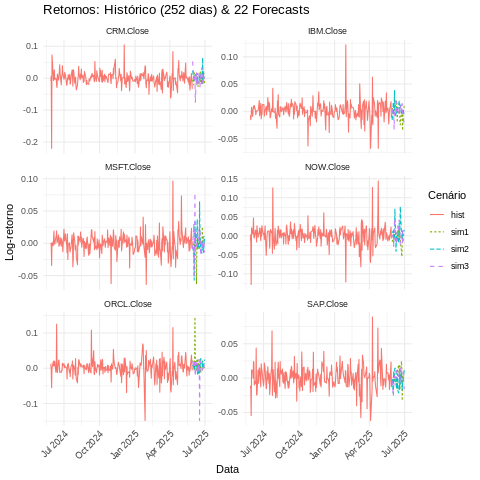

In [ ]:
%%R
# 8) Visualizações

# 8.1) Retornos
ggplot(ret_all, aes(x = date, y = ret, color = .rep, linetype = .rep)) +
  geom_line() +
  facet_wrap(~ asset, scales = "free_y", ncol = 2) +
  labs(
    title    = paste0("Retornos: Histórico (252 dias) & ", n_ahead, " Forecasts"),
    x        = "Data",
    y        = "Log-retorno",
    color    = "Cenário",
    linetype = "Cenário"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))



(`geom_line()`). 



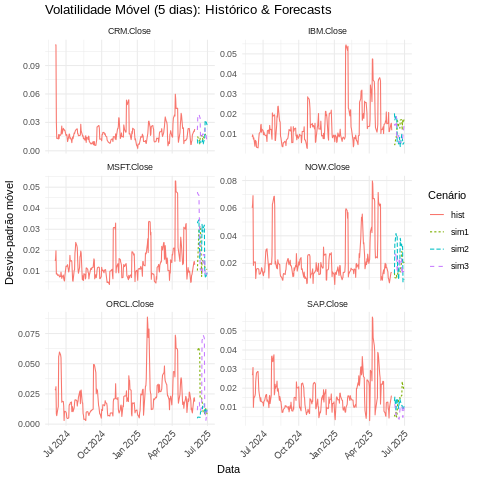

In [ ]:
%%R

# 8.2) Volatilidade móvel
ggplot(ret_all, aes(x = date, y = vol, color = .rep, linetype = .rep)) +
  geom_line() +
  facet_wrap(~ asset, scales = "free_y", ncol = 2) +
  labs(
    title    = paste0("Volatilidade Móvel (", window, " dias): Histórico & Forecasts"),
    x        = "Data",
    y        = "Desvio-padrão móvel",
    color    = "Cenário",
    linetype = "Cenário"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [ ]:
%%R

library(tidyverse)
library(openxlsx)

# supondo que você já tenha o objeto ret_all (com date, asset, ret, .rep, vol)

# 1) cria o workbook
wb <- createWorkbook()

# 2) identifica cenários
cenarios <- unique(ret_all$.rep)

# 3) define estilo numérico (6 casas decimais; Excel no Windows PT-BR exibirá vírgulas)
numStyle <- createStyle(numFmt = "#,##0.000000")

# 4) para cada cenário, pivot e escreve em aba própria
for(s in cenarios) {
  df <- ret_all %>%
    filter(.rep == s) %>%
    select(date, asset, ret, vol) %>%
    pivot_wider(
      names_from  = asset,
      values_from = c(ret, vol),
      names_glue  = "{asset}_{.value}"
    )

  addWorksheet(wb, sheetName = s)
  writeData(wb, sheet = s, x = df, withFilter = TRUE)

  # aplica o estilo numérico em todas as colunas, exceto a data (coluna 1)
  addStyle(
    wb, sheet = s, style = numStyle,
    rows = 2:(nrow(df) + 1),
    cols = 2:ncol(df),
    gridExpand = TRUE
  )
  setColWidths(wb, sheet = s, cols = 1:ncol(df), widths = "auto")
}

# 5) salva o arquivo
saveWorkbook(wb, file = "retornos_e_volatilidades.xlsx", overwrite = TRUE)


## Fronteiras Eficientes via Simulação de Monte Carlo e Plotly

O próximo bloco de código gera, para cada um dos quatro cenários (`hist`, `sim1`, `sim2`, `sim3`), uma **aproximação empírica da fronteira eficiente** usando simulações de Monte Carlo e exibe tudo num gráfico 2×2 interativo com Plotly. Além disso aponta a **carteira de máximo Sharpe** em cada cenário.

### 1. Dados e Pré-processamento  
- Lemos a planilha `retornos_e_volatilidades.xlsx`, que contém colunas `ret_<ativo>` com os **retornos diários simulados**.  
- Para cada cenário $s$, montamos a matriz de retornos
  $$
    R^{(s)} \in \mathbb R^{T\times n},  
    \quad R^{(s)}_{t,j} = \text{retorno do ativo }j\text{ no dia }t.
  $$
- Removemos ativos com dados inválidos (Inf ou NaN) ou variância zero.

### 2. Simulação de Carteiras Aleatórias  
- Geramos $N=50\,000$ vetores de pesos
  $$
    W_i \sim \mathrm{Dirichlet}(1,\dots,1),\quad i=1,\dots,N,
    \;\sum_{j=1}^n w_{ij}=1,\;w_{ij}\ge0.
  $$
- Para cada carteira \(i\), calculamos:
  - **Retorno esperado**  
    $$
      R_i \;=\;\sum_{j=1}^n w_{ij}\,\mu_j,
      \quad \mu_j = \frac1T\sum_{t=1}^T R^{(s)}_{t,j}.
    $$
  - **Risco** (desvio‐padrão ou idealmente GARCH(1,1) com Student-t assimétrica)

### 3. Carteira de Máximo Sharpe  
- O **índice de Sharpe** diário:
  $$
    S_i = \frac{R_i - R_f}{\sigma_i},
    \quad R_f = 0.
  $$
- Seleciona a carteira $i^* = \arg\max_i S_i$ como a solução de **Melhor Relação Retorno/Risco**.

### 4. Fronteira Eficiente Empírica  
- Ordenamos as simulações por retorno $R_i$ crescente.  
- Construímos o envelope de risco mínimo $\sigma$ para cada nível de $R$:
  $$
    \text{fronteira} \;=\;\bigl\{(\sigma_i,R_i)\mid \sigma_i < \min_{j<i}\sigma_j\bigr\}.
  $$

### 5. Visualização com Plotly  
Em cada um dos 4 subplots 2×2:
- **Pontos cinza**: todas as simulações $(\sigma_i,R_i)$.  
- **Linha vermelha**: fronteira eficiente empírica.  
- **Estrela dourada**: carteira de máximo Sharpe.  

O gráfico é interativo: dá zoom, mostra tooltip com valores etc.

---  



In [ ]:

# 1) Instala dependências
!pip install -q pandas numpy openpyxl plotly scipy

# 2) Imports
import glob
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# 3) Localiza o Excel (qualquer nome que comece com 'retornos_e_volatilidades')
excel_files = glob.glob("retornos_e_volatilidades*.xlsx")
if not excel_files:
    raise FileNotFoundError("Nenhum arquivo retornos_e_volatilidades*.xlsx encontrado")
xls_path = excel_files[0]

# 4) Parâmetros de Monte Carlo
N_PORTFOLIOS = 50_000
RISK_FREE    = 0.0

# 5) Carrega todas as abas
xls    = pd.ExcelFile(xls_path)
sheets = xls.sheet_names   # ex: ['hist','sim1','sim2','sim3']

# 6) Prepara figura 2×2 com Plotly
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"Cenário {sc}" for sc in sheets],
    horizontal_spacing=0.1, vertical_spacing=0.15
)

# 7) Loop por cenário
for idx, sc in enumerate(sheets):
    row, col = divmod(idx, 2)
    row += 1; col += 1

    # 7.1) Lê a aba
    df = pd.read_excel(xls_path, sheet_name=sc, index_col=0, parse_dates=True)

    # 7.2) Filtra só as colunas de retorno (suffix "_ret"), renomeando para ticker simples
    rets = (
        df.filter(regex="_ret$")
          .rename(columns=lambda c: c.replace("_ret",""))
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=1, how="any")
    )
    tickers = rets.columns.tolist()
    mu  = rets.mean()
    cov = rets.cov()

    # 7.3) Simula carteiras via Dirichlet
    W = np.random.dirichlet(np.ones(len(tickers)), size=N_PORTFOLIOS)
    port_rets  = W.dot(mu.values)
    port_vars  = np.einsum('ij,jk,ik->i', W, cov.values, W)
    port_risks = np.sqrt(port_vars)

    # 7.4) Encontra o índice de Máx Sharpe
    sharpe = (port_rets - RISK_FREE) / port_risks
    idx_sh  = np.nanargmax(sharpe)
    opt_ret  = port_rets[idx_sh]
    opt_risk = port_risks[idx_sh]

    # 7.5) Constroi a fronteira eficiente empírica
    df_mc   = pd.DataFrame({"risk": port_risks, "ret": port_rets})
    df_mc   = df_mc.sort_values("ret")
    frontier, min_r = [], np.inf
    for r, rtd in zip(df_mc["risk"], df_mc["ret"]):
        if r < min_r:
            frontier.append((r, rtd))
            min_r = r
    frontier = np.array(frontier)

    # 7.6) Traça as simulações (cinza), fronteira (vermelha) e Máx Sharpe (estrela)
    fig.add_trace(
        go.Scatter(
            x=df_mc["risk"], y=df_mc["ret"],
            mode="markers", marker=dict(size=2, opacity=0.15, color="gray"),
            name="Simulações", showlegend=(idx==0)
        ), row=row, col=col
    )
    fig.add_trace(
        go.Scatter(
            x=frontier[:,0], y=frontier[:,1],
            mode="lines", line=dict(color="red", width=2),
            name="Fronteira", showlegend=(idx==0)
        ), row=row, col=col
    )
    fig.add_trace(
        go.Scatter(
            x=[opt_risk], y=[opt_ret],
            mode="markers", marker=dict(symbol="star", size=14, color="gold"),
            name="Máx Sharpe", showlegend=(idx==0)
        ), row=row, col=col
    )

    fig.update_xaxes(title_text="Risco σ",       row=row, col=col)
    fig.update_yaxes(title_text="Retorno Exp.",  row=row, col=col)

# 8) Layout geral
fig.update_layout(
    height=800, width=900,
    title_text="Fronteiras Eficientes (Monte Carlo) por Cenário",
    legend=dict(x=0.85, y=0.05)
)

# 9) Exibe o gráfico
fig.show()



# Otimização Multi-Objetivo Markowitz via Evolução Diferencial (DE) — Cenário **sim1**

Este bloco implementa um modelo de alocação de portfólio que **minimiza risco** e **maximiza retorno** ao mesmo tempo, usando:

- **Modelo de Markowitz (Scalarizado)**  
  $$
    \min_{w}\;\underbrace{w^\top \Sigma\,w}_{\text{variância (risco)}} \;-\;\gamma\;\max \underbrace{\mu^\top w}_{\text{retorno esperado}}
  $$
  sujeito a  
  $$
    \sum_{i=1}^n w_i = 1,\quad w_i \ge w_{\min} \quad(\text{e}\;w_i\le1).
  $$
  Aqui fixamos $\gamma=1$ e $w_{\min}=5\%$.

- **Evolução Diferencial**  
  Um algoritmo genético de otimização numérica que explora **populações** de vetores $x\in[0,1]^n$ para encontrar o $w$ ótimo.  
  A cada iteração, combina vetores, mutaciona, seleciona os melhores segundo a função-objetivo acima.  

---

## Resultados Esperados

1. **Pesos ótimos** $w_i$ para cada ativo no cenário `sim1`, respeitando $w_i\ge5\%$ e soma = 100 %.  
2. **Métricas do portfólio**:  
   - Retorno diário esperado  
   - Risco diário (desvio-padrão)  
   - Índice de Sharpe (com $R_f=0$)  
3. **Gráfico interativo** com Plotly mostrando a alocação em barras percentuais.

In [ ]:

# 1) Instala dependências
!pip install -q scipy pandas numpy openpyxl matplotlib

# 2) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# 3) Carrega os retornos simulados do cenário "sim1"
xls = pd.ExcelFile("retornos_e_volatilidades.xlsx")
df  = pd.read_excel(xls, sheet_name="sim1", index_col=0, parse_dates=True)

# 4) Extrai apenas as colunas de retorno
#     - filtro por sufixo "_ret"
#     - renomeia removendo esse sufixo
rets = (
    df
    .filter(regex="_ret$")                  # todas as colunas que terminam em "_ret"
    .rename(columns=lambda c: c[:-4])       # tira os 4 caracteres finais "_ret"
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1, how="any")
)

tickers = rets.columns.tolist()
n       = len(tickers)
assert n>0, "Não achei colunas de retorno *_ret no Excel!"

# 5) Estatísticas de Markowitz
mu    = rets.mean().values        # retornos médios diários
Sigma = rets.cov().values         # covariância diária

# 6) Restrições de peso
min_w = 0.05                      # mínimo 5% em cada ativo
scale = 1 - n * min_w             # parte restante para distribuir
gamma = 1.0                       # trade-off risco x retorno

# 7) Função objetivo (σ - γ·R)
def markowitz_obj(x):
    raw = np.abs(x)
    if raw.sum() == 0:
        raw = np.ones_like(raw)
    w = min_w + scale * raw / raw.sum()
    port_ret  = mu.dot(w)
    port_risk = np.sqrt(w @ Sigma @ w)
    return port_risk - gamma * port_ret

# 8) Bounds em [0,1]^n
bounds = [(0,1)] * n

# 9) Roda Differential Evolution
res = differential_evolution(
    markowitz_obj,
    bounds,
    strategy      = 'best1bin',
    popsize       = 15,
    mutation      = (0.5, 1),
    recombination = 0.7,
    tol           = 1e-6,
    maxiter       = 1000,
    polish        = True,
    seed          = 42
)

# 10) Converte X → w
x_opt = np.abs(res.x)
w_opt = min_w + scale * x_opt / x_opt.sum()

# 11) Métricas finais
port_ret  = mu.dot(w_opt)
port_risk = np.sqrt(w_opt @ Sigma @ w_opt)
sharpe    = port_ret / port_risk

# 12) Imprime o resultado
print(f"\n=== Alocação Ótima (Markowitz via DE) — sim1 ===\n")
for tkr, w in zip(tickers, w_opt):
    print(f"  {tkr:12s}: {w*100:6.2f}%")
print(f"\nRetorno Médio Diário: {port_ret:.4%}")
print(f"Risco Diário (σ)    : {port_risk:.4%}")
print(f"Sharpe (Rf=0)       : {sharpe:.4f}")

# 13) Gráfico interativo em Plotly
import plotly.express as px

df_w = pd.DataFrame({"Ativo": tickers, "Peso": w_opt})
fig  = px.bar(
    df_w, x="Ativo", y="Peso",
    title="Alocação Ótima de Ativos — sim1",
    text=df_w["Peso"].map(lambda x: f"{x*100:.2f}%")
)
fig.update_traces(marker_color="green", textposition="outside")
fig.update_layout(
    yaxis=dict(title="Peso (%)", tickformat=".1%"),
    xaxis_tickangle=-45,
    uniformtext_minsize=8,
    uniformtext_mode="hide"
)
fig.show()



=== Alocação Ótima (Markowitz via DE) — sim1 ===

  CRM.Close   :  21.28%
  IBM.Close   :  11.64%
  MSFT.Close  :  12.89%
  NOW.Close   :   5.00%
  ORCL.Close  :  13.97%
  SAP.Close   :  35.22%

Retorno Médio Diário: 0.0916%
Risco Diário (σ)    : 0.6664%
Sharpe (Rf=0)       : 0.1374


## Análise de Performance e Drawdown — Carteira Ótima (sim1)

Na próxima célula faremos:

1. **Carregamento dos dados**  
   - Lemos o Excel `retornos_e_volatilidades.xlsx`, aba `sim1`, e extraímos apenas as colunas de retorno `ret_<ativo>`.  
   - Montamos um DataFrame `rets` com as séries de retorno diárias dos 22 dias simulados.

2. **Aplicação dos pesos ótimos**  
   - Já tínhamos calculado em uma célula anterior o vetor `w_opt` com os pesos da carteira via Markowitz+DE.  
   - Multiplicamos:  
$$
r^{(p)}_t = \sum_{j} w_j\,r_{t,j},
$$
     obtendo `port_ret`, a série de retorno diário da carteira.

3. **Cálculo da performance cumulativa**  
   - Normalizamos o capital inicial para 1:  
     $$
       W_0 = 1,\quad
       W_t = \prod_{i=1}^t (1 + r^{(p)}_i).
     $$
   - Resultado em `wealth`, índice de riqueza ao longo dos 22 dias.

4. **Cálculo do drawdown**  
   - Definimos o “pico até hoje”:
$$
\displaystyle \text{peak}_t = \max_{s \le t} W_s.
$$  
   - Drawdown diário:

     $$
      \text{DD}_t = \frac{W_t - \text{peak}_t}{\text{peak}_t}.
     $$
   - Identificamos o **drawdown máximo** como o menor valor de `DD_t`.

5. **Visualização Interativa**  
   - Utilizamos **Plotly** com `make_subplots` para criar dois painéis:
     - **Superior:** curva de `wealth` ao longo do prazo.
     - **Inferior:** área preenchida do `drawdown`, realçando quedas percentuais.
   - O gráfico mostra de forma clara:
     - O **crescimento** acumulado da carteira.
     - O **maior recuo** percentual sofrido.

---

**Por que é útil?**  
- Permite ao decisor ver tanto o **ganho potencial** quanto o **risco de queda** em curto prazo.  
- Dá transparência sobre *quando* e *quanto* a carteira pode retroceder antes de recuperar ganhos.  
- Serve de base para avaliar se o portfólio atende à tolerância ao risco na janela de 22 dias.



In [ ]:

# 1) Imports
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# 2) Carrega retornos simulados do cenário "sim1"
xls = pd.ExcelFile("retornos_e_volatilidades.xlsx")
df  = pd.read_excel(xls, sheet_name="sim1", index_col=0, parse_dates=True)

# 3) Extrai as colunas que terminam em "_ret" e renomeia (tirando o sufixo)
rets = (
    df
    .filter(regex="_ret$")           # pega só colunas com sufixo "_ret"
    .rename(columns=lambda c: c[:-4])# remove os 4 caracteres finais "_ret"
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1, how="any")
)

# Garante que encontramos algo
if rets.shape[1] == 0:
    raise RuntimeError("Não encontrei colunas *_ret no Excel (sim1). Verifique os nomes das abas/colunas.")

# 4) Vetor de pesos 'w_opt' já calculado na célula anterior
# Por exemplo:
# w_opt = np.array([0.42, 0.05, 0.083, 0.05, 0.11, 0.05, 0.2394])

weights = pd.Series(w_opt, index=rets.columns)

# 5) Série de retornos da carteira
port_ret = rets.dot(weights)

# 6) Performance cumulativa (índice de riqueza)
wealth     = (1 + port_ret).cumprod()
running_max = wealth.cummax()
drawdown    = (wealth - running_max) / running_max
max_dd      = drawdown.min()

# 7) Monta gráfico interativo com Plotly
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    row_heights=[0.6, 0.4],
    subplot_titles=[
        "Performance Cumulativa da Carteira Ótima (sim1)",
        f"Drawdown Diário (Máx: {max_dd:.2%})"
    ]
)

# 7.1) Wealth index
fig.add_trace(
    go.Scatter(
        x=wealth.index, y=wealth.values,
        mode="lines", name="Wealth Index"
    ),
    row=1, col=1
)

# 7.2) Drawdown
fig.add_trace(
    go.Scatter(
        x=drawdown.index, y=drawdown.values,
        mode="lines", name="Drawdown",
        fill='tozeroy', line=dict(color='crimson')
    ),
    row=2, col=1
)

# 8) Layout
fig.update_yaxes(title_text="Índice de Riqueza", row=1, col=1)
fig.update_yaxes(title_text="Drawdown", row=2, col=1, tickformat=".0%")
fig.update_xaxes(title_text="Data", row=2, col=1)

fig.update_layout(
    height=600, width=800,
    showlegend=False,
    title_text="Performance e Drawdown da Carteira Ótima — sim1"
)

fig.show()



## Interpretação Objetiva — Carteira Ótima (sim1)

- **Retorno total:** +1,50 % em 22 dias  
- **Retorno médio diário:** ≈ 0,065 %  
- **Pico histórico:** +2,70 % no meio do período  
- **Drawdown máximo:** –1,33 %  
- **Relação Drawdown/Retorno:** 1,33 % / 1,50 % ≈ 0,89  

**Conclusão rápida:**  
A carteira gerou lucro consistente de cerca de 1,5 % com queda máxima limitada a 1,33 %, indicando um trade‐off risco/retorno favorável num horizonte curto.  


#SIM 2


In [ ]:
# 1) Instala dependências
!pip install -q scipy pandas numpy openpyxl matplotlib

# 2) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# 3) Carrega os retornos simulados do cenário "sim1"
xls = pd.ExcelFile("retornos_e_volatilidades.xlsx")
df  = pd.read_excel(xls, sheet_name="sim2", index_col=0, parse_dates=True)

# 4) Extrai apenas as colunas de retorno
#     - filtro por sufixo "_ret"
#     - renomeia removendo esse sufixo
rets = (
    df
    .filter(regex="_ret$")                  # todas as colunas que terminam em "_ret"
    .rename(columns=lambda c: c[:-4])       # tira os 4 caracteres finais "_ret"
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1, how="any")
)

tickers = rets.columns.tolist()
n       = len(tickers)
assert n>0, "Não achei colunas de retorno *_ret no Excel!"

# 5) Estatísticas de Markowitz
mu    = rets.mean().values        # retornos médios diários
Sigma = rets.cov().values         # covariância diária

# 6) Restrições de peso
min_w = 0.05                      # mínimo 5% em cada ativo
scale = 1 - n * min_w             # parte restante para distribuir
gamma = 1.0                       # trade-off risco x retorno

# 7) Função objetivo (σ - γ·R)
def markowitz_obj(x):
    raw = np.abs(x)
    if raw.sum() == 0:
        raw = np.ones_like(raw)
    w = min_w + scale * raw / raw.sum()
    port_ret  = mu.dot(w)
    port_risk = np.sqrt(w @ Sigma @ w)
    return port_risk - gamma * port_ret

# 8) Bounds em [0,1]^n
bounds = [(0,1)] * n

# 9) Roda Differential Evolution
res = differential_evolution(
    markowitz_obj,
    bounds,
    strategy      = 'best1bin',
    popsize       = 15,
    mutation      = (0.5, 1),
    recombination = 0.7,
    tol           = 1e-6,
    maxiter       = 1000,
    polish        = True,
    seed          = 42
)

# 10) Converte X → w
x_opt = np.abs(res.x)
w_opt = min_w + scale * x_opt / x_opt.sum()

# 11) Métricas finais
port_ret  = mu.dot(w_opt)
port_risk = np.sqrt(w_opt @ Sigma @ w_opt)
sharpe    = port_ret / port_risk

# 12) Imprime o resultado
print(f"\n=== Alocação Ótima (Markowitz via DE) — sim2 ===\n")
for tkr, w in zip(tickers, w_opt):
    print(f"  {tkr:12s}: {w*100:6.2f}%")
print(f"\nRetorno Médio Diário: {port_ret:.4%}")
print(f"Risco Diário (σ)    : {port_risk:.4%}")
print(f"Sharpe (Rf=0)       : {sharpe:.4f}")

# 13) Gráfico interativo em Plotly
import plotly.express as px

df_w = pd.DataFrame({"Ativo": tickers, "Peso": w_opt})
fig  = px.bar(
    df_w, x="Ativo", y="Peso",
    title="Alocação Ótima de Ativos — sim2",
    text=df_w["Peso"].map(lambda x: f"{x*100:.2f}%")
)
fig.update_traces(marker_color="green", textposition="outside")
fig.update_layout(
    yaxis=dict(title="Peso (%)", tickformat=".1%"),
    xaxis_tickangle=-45,
    uniformtext_minsize=8,
    uniformtext_mode="hide"
)
fig.show()


=== Alocação Ótima (Markowitz via DE) — sim2 ===

  CRM.Close   :  14.04%
  IBM.Close   :  33.68%
  MSFT.Close  :   5.00%
  NOW.Close   :   5.00%
  ORCL.Close  :  37.28%
  SAP.Close   :   5.00%

Retorno Médio Diário: 0.4134%
Risco Diário (σ)    : 0.6136%
Sharpe (Rf=0)       : 0.6737


In [ ]:

# 1) Imports
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# 2) Carrega retornos simulados do cenário "sim1"
xls = pd.ExcelFile("retornos_e_volatilidades.xlsx")
df  = pd.read_excel(xls, sheet_name="sim2", index_col=0, parse_dates=True)

# 3) Extrai as colunas que terminam em "_ret" e renomeia (tirando o sufixo)
rets = (
    df
    .filter(regex="_ret$")           # pega só colunas com sufixo "_ret"
    .rename(columns=lambda c: c[:-4])# remove os 4 caracteres finais "_ret"
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1, how="any")
)

# Garante que encontramos algo
if rets.shape[1] == 0:
    raise RuntimeError("Não encontrei colunas *_ret no Excel (sim1). Verifique os nomes das abas/colunas.")

# 4) Vetor de pesos 'w_opt' já calculado na célula anterior
# Por exemplo:
# w_opt = np.array([0.42, 0.05, 0.083, 0.05, 0.11, 0.05, 0.2394])

weights = pd.Series(w_opt, index=rets.columns)

# 5) Série de retornos da carteira
port_ret = rets.dot(weights)

# 6) Performance cumulativa (índice de riqueza)
wealth     = (1 + port_ret).cumprod()
running_max = wealth.cummax()
drawdown    = (wealth - running_max) / running_max
max_dd      = drawdown.min()

# 7) Monta gráfico interativo com Plotly
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    row_heights=[0.6, 0.4],
    subplot_titles=[
        "Performance Cumulativa da Carteira Ótima (sim2)",
        f"Drawdown Diário (Máx: {max_dd:.2%})"
    ]
)

# 7.1) Wealth index
fig.add_trace(
    go.Scatter(
        x=wealth.index, y=wealth.values,
        mode="lines", name="Wealth Index"
    ),
    row=1, col=1
)

# 7.2) Drawdown
fig.add_trace(
    go.Scatter(
        x=drawdown.index, y=drawdown.values,
        mode="lines", name="Drawdown",
        fill='tozeroy', line=dict(color='crimson')
    ),
    row=2, col=1
)

# 8) Layout
fig.update_yaxes(title_text="Índice de Riqueza", row=1, col=1)
fig.update_yaxes(title_text="Drawdown", row=2, col=1, tickformat=".0%")
fig.update_xaxes(title_text="Data", row=2, col=1)

fig.update_layout(
    height=600, width=800,
    showlegend=False,
    title_text="Performance e Drawdown da Carteira Ótima — sim2"
)

fig.show()



In [ ]:
# 1) Instala dependências
!pip install -q scipy pandas numpy openpyxl matplotlib

# 2) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# 3) Carrega os retornos simulados do cenário "sim1"
xls = pd.ExcelFile("retornos_e_volatilidades.xlsx")
df  = pd.read_excel(xls, sheet_name="sim3", index_col=0, parse_dates=True)

# 4) Extrai apenas as colunas de retorno
#     - filtro por sufixo "_ret"
#     - renomeia removendo esse sufixo
rets = (
    df
    .filter(regex="_ret$")                  # todas as colunas que terminam em "_ret"
    .rename(columns=lambda c: c[:-4])       # tira os 4 caracteres finais "_ret"
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1, how="any")
)

tickers = rets.columns.tolist()
n       = len(tickers)
assert n>0, "Não achei colunas de retorno *_ret no Excel!"

# 5) Estatísticas de Markowitz
mu    = rets.mean().values        # retornos médios diários
Sigma = rets.cov().values         # covariância diária

# 6) Restrições de peso
min_w = 0.05                      # mínimo 5% em cada ativo
scale = 1 - n * min_w             # parte restante para distribuir
gamma = 1.0                       # trade-off risco x retorno

# 7) Função objetivo (σ - γ·R)
def markowitz_obj(x):
    raw = np.abs(x)
    if raw.sum() == 0:
        raw = np.ones_like(raw)
    w = min_w + scale * raw / raw.sum()
    port_ret  = mu.dot(w)
    port_risk = np.sqrt(w @ Sigma @ w)
    return port_risk - gamma * port_ret

# 8) Bounds em [0,1]^n
bounds = [(0,1)] * n

# 9) Roda Differential Evolution
res = differential_evolution(
    markowitz_obj,
    bounds,
    strategy      = 'best1bin',
    popsize       = 15,
    mutation      = (0.5, 1),
    recombination = 0.7,
    tol           = 1e-6,
    maxiter       = 1000,
    polish        = True,
    seed          = 42
)

# 10) Converte X → w
x_opt = np.abs(res.x)
w_opt = min_w + scale * x_opt / x_opt.sum()

# 11) Métricas finais
port_ret  = mu.dot(w_opt)
port_risk = np.sqrt(w_opt @ Sigma @ w_opt)
sharpe    = port_ret / port_risk

# 12) Imprime o resultado
print(f"\n=== Alocação Ótima (Markowitz via DE) — sim3 ===\n")
for tkr, w in zip(tickers, w_opt):
    print(f"  {tkr:12s}: {w*100:6.2f}%")
print(f"\nRetorno Médio Diário: {port_ret:.4%}")
print(f"Risco Diário (σ)    : {port_risk:.4%}")
print(f"Sharpe (Rf=0)       : {sharpe:.4f}")

# 13) Gráfico interativo em Plotly
import plotly.express as px

df_w = pd.DataFrame({"Ativo": tickers, "Peso": w_opt})
fig  = px.bar(
    df_w, x="Ativo", y="Peso",
    title="Alocação Ótima de Ativos — sim1",
    text=df_w["Peso"].map(lambda x: f"{x*100:.2f}%")
)
fig.update_traces(marker_color="green", textposition="outside")
fig.update_layout(
    yaxis=dict(title="Peso (%)", tickformat=".1%"),
    xaxis_tickangle=-45,
    uniformtext_minsize=8,
    uniformtext_mode="hide"
)
fig.show()


=== Alocação Ótima (Markowitz via DE) — sim3 ===

  CRM.Close   :   5.64%
  IBM.Close   :  19.87%
  MSFT.Close  :   5.00%
  NOW.Close   :  24.16%
  ORCL.Close  :  11.68%
  SAP.Close   :  33.66%

Retorno Médio Diário: 0.1079%
Risco Diário (σ)    : 0.6833%
Sharpe (Rf=0)       : 0.1580


In [ ]:

# 1) Imports
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# 2) Carrega retornos simulados do cenário "sim1"
xls = pd.ExcelFile("retornos_e_volatilidades.xlsx")
df  = pd.read_excel(xls, sheet_name="sim3", index_col=0, parse_dates=True)

# 3) Extrai as colunas que terminam em "_ret" e renomeia (tirando o sufixo)
rets = (
    df
    .filter(regex="_ret$")           # pega só colunas com sufixo "_ret"
    .rename(columns=lambda c: c[:-4])# remove os 4 caracteres finais "_ret"
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1, how="any")
)

# Garante que encontramos algo
if rets.shape[1] == 0:
    raise RuntimeError("Não encontrei colunas *_ret no Excel (sim1). Verifique os nomes das abas/colunas.")

# 4) Vetor de pesos 'w_opt' já calculado na célula anterior
# Por exemplo:
# w_opt = np.array([0.42, 0.05, 0.083, 0.05, 0.11, 0.05, 0.2394])

weights = pd.Series(w_opt, index=rets.columns)

# 5) Série de retornos da carteira
port_ret = rets.dot(weights)

# 6) Performance cumulativa (índice de riqueza)
wealth     = (1 + port_ret).cumprod()
running_max = wealth.cummax()
drawdown    = (wealth - running_max) / running_max
max_dd      = drawdown.min()

# 7) Monta gráfico interativo com Plotly
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    row_heights=[0.6, 0.4],
    subplot_titles=[
        "Performance Cumulativa da Carteira Ótima (sim3)",
        f"Drawdown Diário (Máx: {max_dd:.2%})"
    ]
)

# 7.1) Wealth index
fig.add_trace(
    go.Scatter(
        x=wealth.index, y=wealth.values,
        mode="lines", name="Wealth Index"
    ),
    row=1, col=1
)

# 7.2) Drawdown
fig.add_trace(
    go.Scatter(
        x=drawdown.index, y=drawdown.values,
        mode="lines", name="Drawdown",
        fill='tozeroy', line=dict(color='crimson')
    ),
    row=2, col=1
)

# 8) Layout
fig.update_yaxes(title_text="Índice de Riqueza", row=1, col=1)
fig.update_yaxes(title_text="Drawdown", row=2, col=1, tickformat=".0%")
fig.update_xaxes(title_text="Data", row=2, col=1)

fig.update_layout(
    height=600, width=800,
    showlegend=False,
    title_text="Performance e Drawdown da Carteira Ótima — sim3"
)

fig.show()

